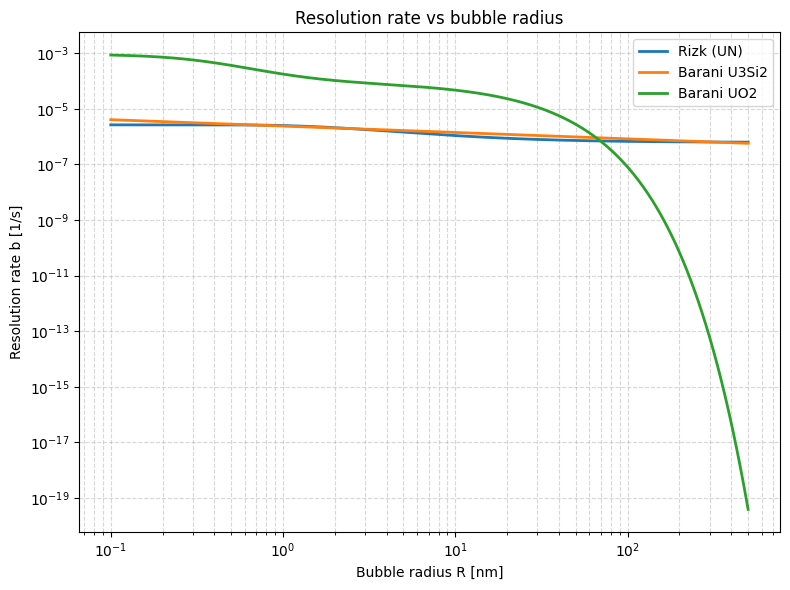


===== Resolution rate values =====

Rizk (UN):
  R_min = 1.000e-01 nm → b = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.247e-06 s^-1
  R_max = 5.012e+02 nm → b = 6.305e-07 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.525e-06 s^-1
  R_max = 5.012e+02 nm → b = 5.714e-07 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b = 5.811e-05 s^-1
  R_max = 5.012e+02 nm → b = 3.877e-20 s^-1


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
F = 1e19  # fission rate [m^-3 s^-1]

# Range R: 0.1 nm → 500 nm
R = np.logspace(-10, -6.3, 500)  # in metri (~1e-10 → ~5e-7)

# =========================
# 1. Rizk (UN)
# =========================
b0_rizk = 1e-25 * (2.64 - 2.02 * np.exp(-2.61e-9 / R))
b_rizk = b0_rizk * F

# =========================
# 2. Barani (U3Si2)
# =========================
b0_barani_si = 2.80e-25 * (5e-10 / R)**0.23
b_barani_si = b0_barani_si * F

# =========================
# 3. Barani (UO2)
# =========================
a = 9.49e-24
b0 = 9.18e-23
b1 = 7.07e7
c = 7.982e18
d = 3.71e16

b0_barani_uo2 = (
    a * np.exp(-b1 * R)
    + ((b0 - a) / (1 + c * R**2)) * np.exp(-d * R**2)
)

b_barani_uo2 = b0_barani_uo2 * F

# =========================
# Plot
# =========================
plt.figure(figsize=(8,6))

plt.loglog(R*1e9, b_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(R*1e9, b_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(R*1e9, b_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('Resolution rate b [1/s]')
plt.title('Resolution rate vs bubble radius')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)  # media logaritmica (più corretta qui)

print("\n===== Resolution rate values =====")

def print_values(name, b_array):
    b_min = b_array[0]
    b_max = b_array[-1]
    
    # trova il valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = b_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b = {b_max:.3e} s^-1")

# stampa per i tre modelli
print_values("Rizk (UN)", b_rizk)
print_values("Barani (U3Si2)", b_barani_si)
print_values("Barani (UO2)", b_barani_uo2)

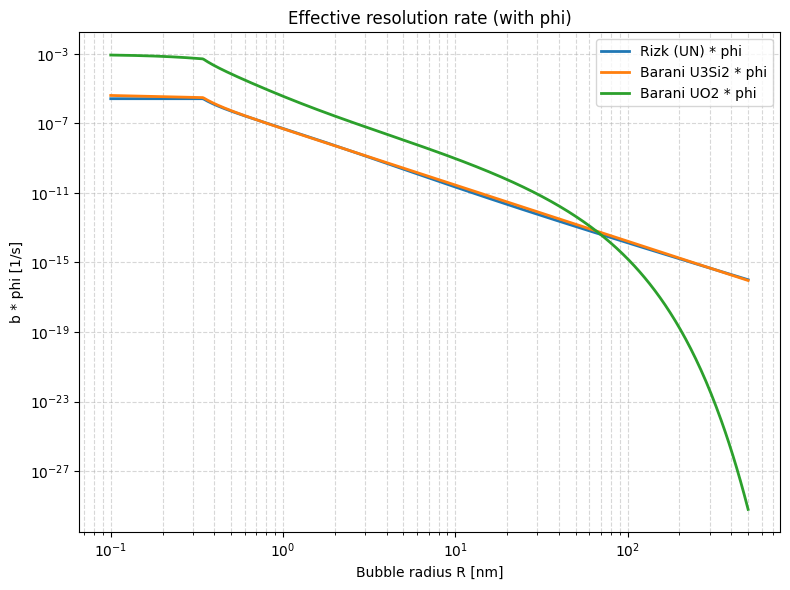


===== Resolution rate * phi =====

Rizk (UN):
  R_min = 1.000e-01 nm → b·phi = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 7.319e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 1.016e-16 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b·phi = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 8.949e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 9.210e-17 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b·phi = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b·phi = 3.410e-09 s^-1
  R_max = 5.012e+02 nm → b·phi = 6.249e-30 s^-1


In [8]:
# =========================
# Phi e m(R)
# =========================

Omega_fg = 8.5e-29  # [m^3]

# numero medio di atomi nella bolla
m = (4/3) * np.pi * R**3 / Omega_fg
m_safe = np.maximum(m, 2.0)

# phi
phi = 1 / (m_safe - 1)

# =========================
# b * phi
# =========================
bphi_rizk = b_rizk * phi
bphi_barani_si = b_barani_si * phi
bphi_barani_uo2 = b_barani_uo2 * phi

plt.figure(figsize=(8,6))

plt.loglog(R*1e9, bphi_rizk, label='Rizk (UN) * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_si, label='Barani U3Si2 * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_uo2, label='Barani UO2 * phi', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('b * phi [1/s]')
plt.title('Effective resolution rate (with phi)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici (b * phi)
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)

print("\n===== Resolution rate * phi =====")

def print_values(name, bphi_array):
    b_min = bphi_array[0]
    b_max = bphi_array[-1]
    
    # indice del valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = bphi_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b·phi = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b·phi = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b·phi = {b_max:.3e} s^-1")

# stampa
print_values("Rizk (UN)", bphi_rizk)
print_values("Barani (U3Si2)", bphi_barani_si)
print_values("Barani (UO2)", bphi_barani_uo2)

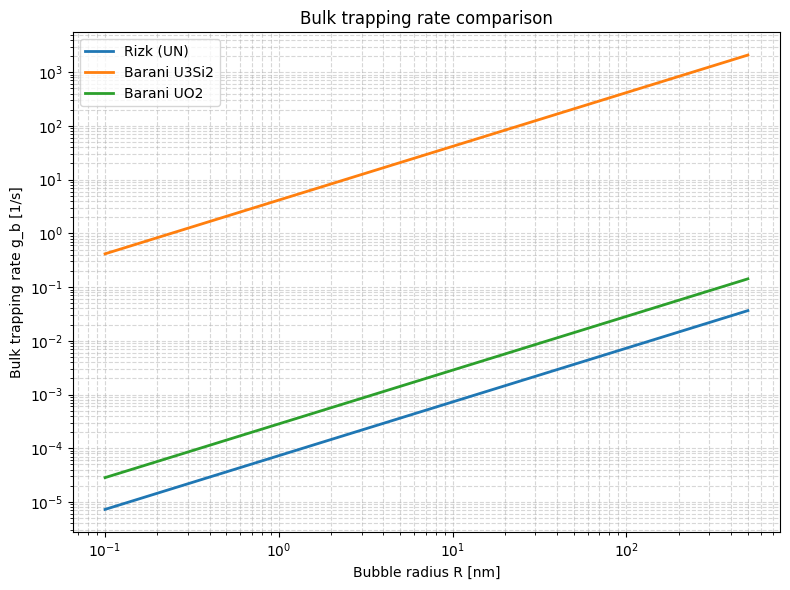


===== Bulk trapping rate =====

Rizk (UN):
  R_min = 1.000e-01 nm → g = 7.268e-06 s^-1
  R_mid = 7.079e+00 nm → g = 5.102e-04 s^-1
  R_max = 5.012e+02 nm → g = 3.643e-02 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → g = 4.154e-01 s^-1
  R_mid = 7.079e+00 nm → g = 2.916e+01 s^-1
  R_max = 5.012e+02 nm → g = 2.082e+03 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → g = 2.837e-05 s^-1
  R_mid = 7.079e+00 nm → g = 1.991e-03 s^-1
  R_max = 5.012e+02 nm → g = 1.422e-01 s^-1


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

T = 1500            # temperatura [K]
F = 1e19            # fission rate [m^-3 s^-1]
N = 1e23            # concentrazione bolle [bub/m^3] (scegli tu!)

# Range R: 0.1 nm → 500 nm
R = np.logspace(-10, -6.3, 500)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(R*1e9, g_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(R*1e9, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(R*1e9, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title('Bulk trapping rate comparison')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)

print("\n===== Bulk trapping rate =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(R - R_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → g = {g_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → g = {g_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

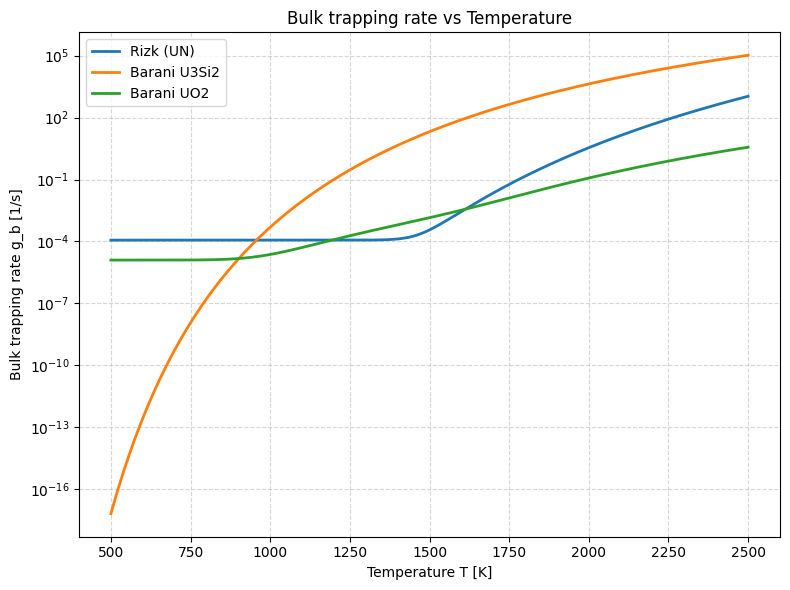


===== Bulk trapping rate vs T =====

Rizk (UN):
  T_min = 500.0 K → g = 1.162e-04 s^-1
  T_mid = 1500.0 K → g = 3.511e-04 s^-1
  T_max = 2500.0 K → g = 1.077e+03 s^-1

Barani (U3Si2):
  T_min = 500.0 K → g = 6.497e-18 s^-1
  T_mid = 1500.0 K → g = 2.019e+01 s^-1
  T_max = 2500.0 K → g = 1.043e+05 s^-1

Barani (UO2):
  T_min = 500.0 K → g = 1.257e-05 s^-1
  T_mid = 1500.0 K → g = 1.395e-03 s^-1
  T_max = 2500.0 K → g = 3.684e+00 s^-1


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

F = 1e19          # fission rate [m^-3 s^-1]
R = 5e-9          # raggio bolla [m] (es: 5 nm)
N = 1e23          # concentrazione bolle [bub/m^3]

# Range temperatura
T = np.linspace(500, 2500, 500)   # [K]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.semilogy(T, g_rizk, label='Rizk (UN)', linewidth=2)
plt.semilogy(T, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.semilogy(T, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Temperature T [K]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title('Bulk trapping rate vs Temperature')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

T_min = T[0]
T_max = T[-1]
T_mid = 0.5 * (T_min + T_max)

print("\n===== Bulk trapping rate vs T =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(T - T_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  T_min = {T_min:.1f} K → g = {g_min:.3e} s^-1")
    print(f"  T_mid = {T_mid:.1f} K → g = {g_mid:.3e} s^-1")
    print(f"  T_max = {T_max:.1f} K → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

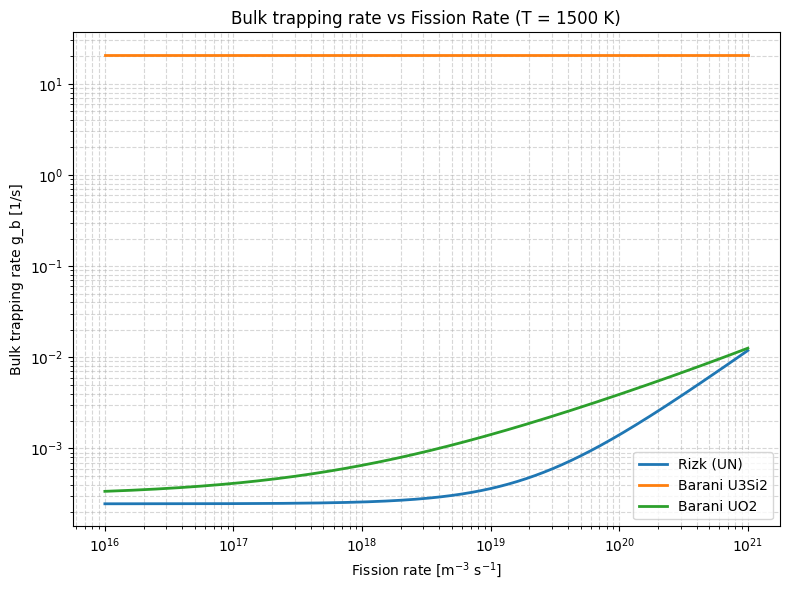


===== Bulk trapping rate vs F =====

Rizk (UN):
  F_min = 1.000e+16 → g = 2.473e-04 s^-1
  F_mid = 3.162e+18 → g = 2.835e-04 s^-1
  F_max = 1.000e+21 → g = 1.187e-02 s^-1

Barani (U3Si2):
  F_min = 1.000e+16 → g = 2.077e+01 s^-1
  F_mid = 3.162e+18 → g = 2.077e+01 s^-1
  F_max = 1.000e+21 → g = 2.077e+01 s^-1

Barani (UO2):
  F_min = 1.000e+16 → g = 3.386e-04 s^-1
  F_mid = 3.162e+18 → g = 9.238e-04 s^-1
  F_max = 1.000e+21 → g = 1.258e-02 s^-1


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

T = 1500          # temperatura [K]
R = 5e-9          # raggio bolla [m]
N = 1e23          # concentrazione bolle [bub/m^3]

# Range fission rate
F = np.logspace(16, 21, 500)   # [m^-3 s^-1]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))


g_barani_si = np.full_like(F, 4 * np.pi * D_barani_si * R * N)

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(F, g_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(F, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(F, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Fission rate [m$^{-3}$ s$^{-1}$]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title(f'Bulk trapping rate vs Fission Rate (T = {T} K)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

F_min = F[0]
F_max = F[-1]
F_mid = np.sqrt(F_min * F_max)

print("\n===== Bulk trapping rate vs F =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(F - F_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  F_min = {F_min:.3e} → g = {g_min:.3e} s^-1")
    print(f"  F_mid = {F_mid:.3e} → g = {g_mid:.3e} s^-1")
    print(f"  F_max = {F_max:.3e} → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

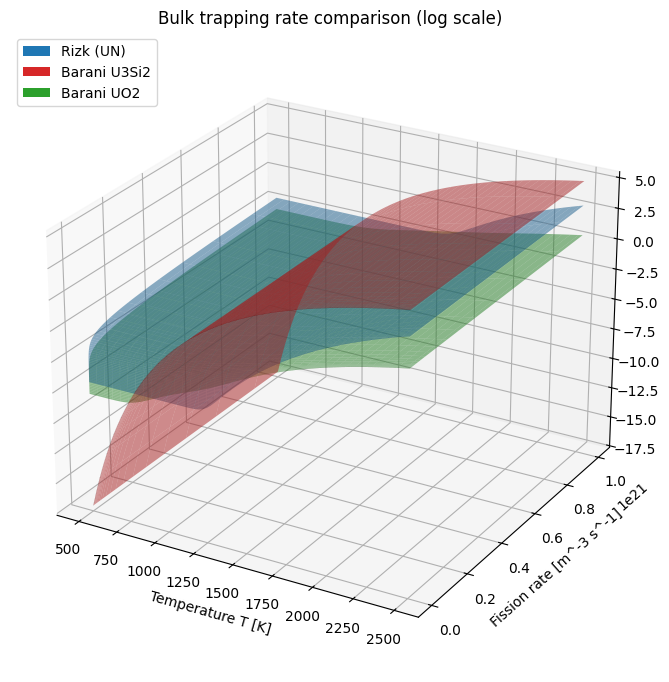

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch

# =========================
# Parametri
# =========================

R = 5e-9
N = 1e23

T = np.linspace(500, 2500, 80)
F = np.logspace(16, 21, 80)

T_grid, F_grid = np.meshgrid(T, F)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3_rizk = 1.85e-39 * F_grid
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T_grid))
g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T_grid))
D2 = 5.64e-25 * np.sqrt(F_grid) * np.exp(-1.91e-19 / (kB_J * T_grid))
D3 = 2.0e-40 * F_grid

D_uo2 = D1 + D2 + D3
g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# LOG10 (con protezione)
# =========================

eps = 1e-30  # evita log(0)

g_rizk_log = np.log10(np.maximum(g_rizk, eps))
g_barani_si_log = np.log10(np.maximum(g_barani_si, eps))
g_barani_uo2_log = np.log10(np.maximum(g_barani_uo2, eps))

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

# Colori (più belli da paper)
blue = '#1f77b4'
red = '#d62728'
green = '#2ca02c'

# Superfici
ax.plot_surface(T_grid, F_grid, g_rizk_log, color=blue, alpha=0.5)
ax.plot_surface(T_grid, F_grid, g_barani_si_log, color=red, alpha=0.5)
ax.plot_surface(T_grid, F_grid, g_barani_uo2_log, color=green, alpha=0.5)

# Labels
ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('Fission rate [m^-3 s^-1]')
ax.set_zlabel('log10(g_b) [1/s]', labelpad=15)

ax.set_title('Bulk trapping rate comparison (log scale)')

# Vista migliore
ax.view_init(elev=25, azim=-60)

# Legenda (proxy objects)
legend_elements = [
    Patch(facecolor=blue, label='Rizk (UN)'),
    Patch(facecolor=red, label='Barani U3Si2'),
    Patch(facecolor=green, label='Barani UO2')
]

ax.legend(handles=legend_elements, loc='upper left')

# Layout fix
plt.subplots_adjust(left=0.05, right=0.82, bottom=0.1, top=0.9)

plt.show()

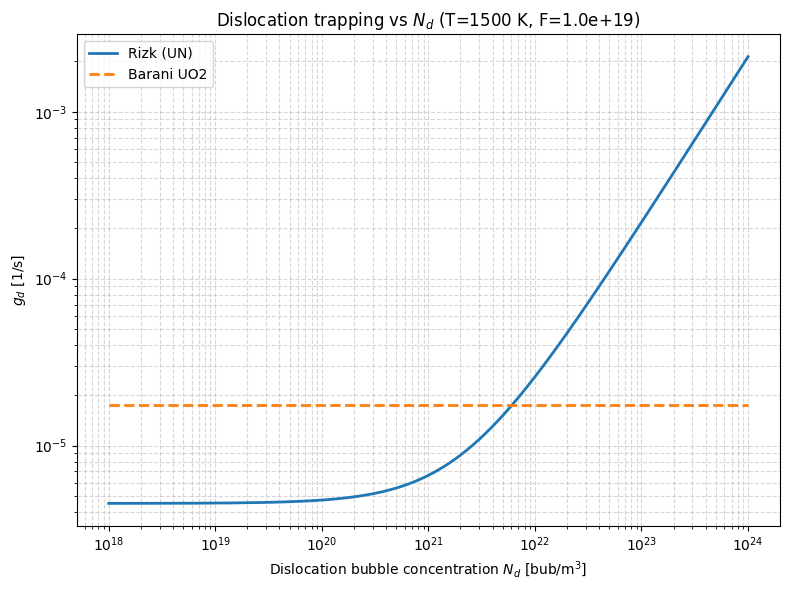

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

T = 1500          # [K]
F = 1e19          # [m^-3 s^-1]
R_d = 5e-9        # [m]

# Range Nd
N_d = np.logspace(18, 24, 500)  # [bub/m^3]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

# Diffusività
D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

# Parametri UN
rho_d = 3.0e13
r_d = 3.46e-10
Z_d = 5.0

Gamma_d = 1 / np.sqrt(np.pi * rho_d)

# Termini
term_bubbles = 4 * np.pi * D_g * R_d * N_d

term_pipe = (
    (2 * np.pi * D_g) /
    (np.log(Gamma_d / (Z_d * r_d)) - 5/3)
) * (rho_d - 2 * R_d * N_d)

g_d_rizk = term_bubbles + term_pipe

# =========================
# 2. Barani (UO2)
# =========================

kB_J = 1.38e-23

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

rho_d_uo2 = 4.0e13
r_d_uo2 = 1.925e-9

r_ws_d = 1 / np.sqrt(np.pi * rho_d_uo2)

term_bubbles_uo2 = 4 * np.pi * D_uo2 * R_d * N_d

term_pipe_uo2 = (
    (2 * np.pi * D_uo2) /
    (np.log(r_ws_d / r_d_uo2) - 3/5)
) * rho_d_uo2

g_d_uo2 = term_bubbles_uo2 + term_pipe_uo2



# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(N_d, g_d_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(N_d, g_d_uo2_array, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Dislocation bubble concentration $N_d$ [bub/m$^3$]')
plt.ylabel('$g_d$ [1/s]')
plt.title(f'Dislocation trapping vs $N_d$ (T={T} K, F={F:.1e})')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()